In [6]:
#----------------------------------------------EX1-------------------------------------

import numpy as np
import matplotlib.pyplot as plt

def hat_matrix(X):
    XtX = X.T @ X
    reg = 1e-8 * np.eye(XtX.shape[0])
    H = X @ np.linalg.pinv(XtX + reg) @ X.T
    return H

def leverage_scores(X):
    return np.diag(hat_matrix(X))

def topk_idx(arr, k=5):
    k = min(k, len(arr))
    return np.argpartition(arr, -k)[-k:]

In [3]:
rng = np.random.default_rng(0)

# model: y = a*x + b + eps
a, b = 2.0, -1.0

mus = [0.0, 1.0]         
sigmas = [0.2, 1.0, 3.0] 

n_regular = 180
n_each_cat = 20  
n_total = n_regular + 3*n_each_cat

def make_dataset(mu, sigma, seed=0):
    rng = np.random.default_rng(seed)
    x_reg = rng.uniform(0, 5, size=n_regular)
    eps_reg = rng.normal(mu, sigma, size=n_regular)
    y_reg = a * x_reg + b + eps_reg
    lab_reg = np.full(n_regular, 0) 

    x_hix = rng.uniform(-10, 15, size=n_each_cat)
    eps_hix = rng.normal(mu, sigma, size=n_each_cat)
    y_hix = a * x_hix + b + eps_hix
    lab_hix = np.full(n_each_cat, 1)

    x_hiy = rng.uniform(0, 5, size=n_each_cat)
    eps_hiy = rng.normal(mu, 4*sigma + 1.0, size=n_each_cat)  
    y_hiy = a * x_hiy + b + eps_hiy
    lab_hiy = np.full(n_each_cat, 2)

    x_both = rng.uniform(-10, 15, size=n_each_cat)
    eps_both = rng.normal(mu, 4*sigma + 1.0, size=n_each_cat)
    y_both = a * x_both + b + eps_both
    lab_both = np.full(n_each_cat, 3)

    x = np.concatenate([x_reg, x_hix, x_hiy, x_both])
    y = np.concatenate([y_reg, y_hix, y_hiy, y_both])
    cat = np.concatenate([lab_reg, lab_hix, lab_hiy, lab_both])

    X = np.c_[np.ones_like(x), x]
    lev = leverage_scores(X)
    return x, y, cat, lev

x_, y_, cat_, lev_ = make_dataset(mu=0.0, sigma=1.0, seed=1)
x_.shape, y_.shape, cat_.shape, lev_[:5]


((240,),
 (240,),
 (240,),
 array([0.00416825, 0.006085  , 0.00568949, 0.00606871, 0.00464192]))

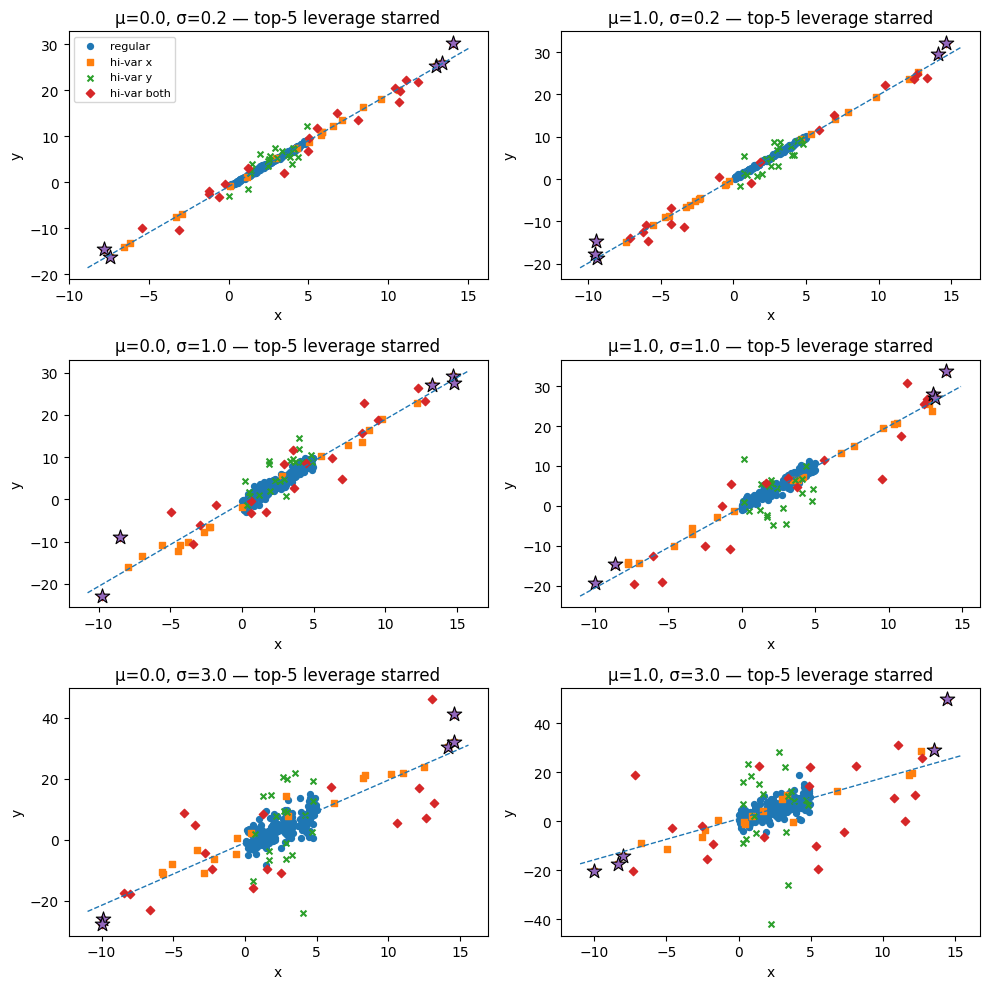

In [4]:
K = 5  

fig, axes = plt.subplots(len(sigmas), len(mus), figsize=(10, 10), squeeze=False)
for i, sigma in enumerate(sigmas):
    for j, mu in enumerate(mus):
        ax = axes[i, j]
        x, y, cat, lev = make_dataset(mu=mu, sigma=sigma, seed=10 + i*10 + j)

        markers = {0: "o", 1: "s", 2: "x", 3: "D"}
        labels  = {0: "regular", 1: "hi-var x", 2: "hi-var y", 3: "hi-var both"}
        for c in np.unique(cat):
            m = markers.get(int(c), "o")
            ax.scatter(x[cat==c], y[cat==c], s=18, marker=m, label=labels[int(c)])

        X = np.c_[np.ones_like(x), x]
        beta = np.linalg.pinv(X) @ y
        xx = np.linspace(x.min()-1, x.max()+1, 200)
        yy = beta[0] + beta[1]*xx
        ax.plot(xx, yy, linestyle="--", linewidth=1)

        idx_top = topk_idx(lev, K)
        ax.scatter(x[idx_top], y[idx_top], s=120, marker="*", edgecolors="k", linewidths=0.8)

        ax.set_title(f"μ={mu}, σ={sigma} — top-{K} leverage starred")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        if i == 0 and j == 0:
            ax.legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()


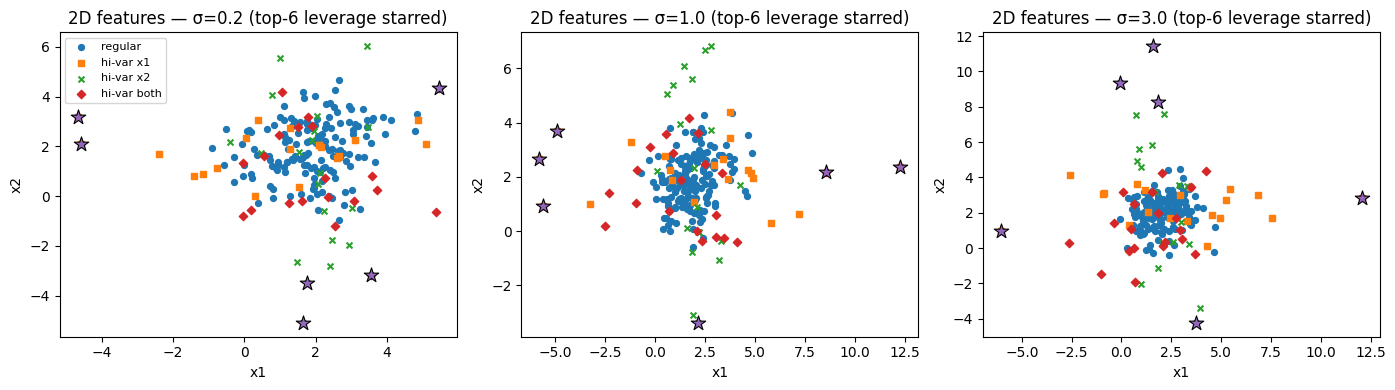

In [5]:
rng = np.random.default_rng(123)
a, b, c = 1.5, -0.8, 0.5

def make_dataset_2d(mu, sigma, seed=0):
    rng = np.random.default_rng(seed)
    mean = [2.0, 2.0]
    cov  = [[1.0, 0.2],
            [0.2, 1.0]]
    Xr = rng.multivariate_normal(mean, cov, size=160)

    Xx = np.column_stack([
        rng.normal(2.0, 4.0, size=20),
        rng.normal(2.0, 1.0, size=20)
    ])

    Xy = np.column_stack([
        rng.normal(2.0, 1.0, size=20),
        rng.normal(2.0, 4.0, size=20)
    ])

    mean_b = [2.0, 2.0]
    cov_b  = [[4.0, 0.0],
              [0.0, 4.0]]
    Xb = rng.multivariate_normal(mean_b, cov_b, size=20)

    X = np.vstack([Xr, Xx, Xy, Xb])
    cat = np.array([0]*len(Xr) + [1]*len(Xx) + [2]*len(Xy) + [3]*len(Xb))

    eps = rng.normal(mu, sigma, size=len(X))
    y = a*X[:,0] + b*X[:,1] + c + eps

    Xdm = np.c_[np.ones(len(X)), X]
    lev = leverage_scores(Xdm)
    return X, y, cat, lev

sigmas2 = [0.2, 1.0, 3.0]
K = 6

fig, axes = plt.subplots(1, len(sigmas2), figsize=(14, 4), squeeze=False)
for j, sigma in enumerate(sigmas2):
    ax = axes[0, j]
    X, y, cat, lev = make_dataset_2d(mu=0.0, sigma=sigma, seed=55 + j)

    markers = {0: "o", 1: "s", 2: "x", 3: "D"}
    labels  = {0: "regular", 1: "hi-var x1", 2: "hi-var x2", 3: "hi-var both"}
    for cval in np.unique(cat):
        m = markers.get(int(cval), "o")
        ax.scatter(X[cat==cval,0], X[cat==cval,1], s=18, marker=m, label=labels[int(cval)])

    idx_top = topk_idx(lev, K)
    ax.scatter(X[idx_top,0], X[idx_top,1], s=120, marker="*", edgecolors="k", linewidths=0.8)

    ax.set_title(f"2D features — σ={sigma} (top-{K} leverage starred)")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    if j == 0:
        ax.legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
#---------------------------------------EX2---------------------------------

import numpy as np
from pyod.utils.data import generate_data
def make_clustered_2d(n_train=400, n_test=100, cont=0.1, seed=42):
    rng = np.random.default_rng(seed)

  
    X1_tr, X1_te, y1_tr, y1_te = generate_data(
        n_train=n_train//2, n_test=n_test//2, n_features=2,
        contamination=cont, random_state=rng.integers(0, 10_000)
    )
    
    shift = rng.normal(2.2, 0.4, size=(1, 2))  
    X2_tr, X2_te, y2_tr, y2_te = generate_data(
        n_train=n_train - n_train//2, n_test=n_test - n_test//2, n_features=2,
        contamination=cont, random_state=rng.integers(0, 10_000)
    )
    X2_tr = X2_tr + shift
    X2_te = X2_te + shift

    X_train = np.vstack([X1_tr, X2_tr])
    X_test  = np.vstack([X1_te, X2_te])
    y_train = np.concatenate([y1_tr, y2_tr]).astype(int)
    y_test  = np.concatenate([y1_te, y2_te]).astype(int)

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = make_clustered_2d()
X_train.shape, X_test.shape, np.bincount(y_train), np.bincount(y_test)


((400, 2), (100, 2), array([360,  40]), array([90, 10]))

In [9]:
from pyod.models.knn import KNN
from sklearn.metrics import confusion_matrix, roc_curve, auc

def eval_knn(X_train, X_test, y_test, k=5, contamination=0.1):
    clf = KNN(n_neighbors=k, contamination=contamination)
    clf.fit(X_train)

    y_pred = clf.predict(X_test)
    scores = clf.decision_function(X_test)  

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    tpr = tp / (tp + fn) if (tp + fn) else 0.0
    tnr = tn / (tn + fp) if (tn + fp) else 0.0
    ba  = 0.5*(tpr + tnr)

    fpr, tpr_pts, _ = roc_curve(y_test, scores)
    auc_val = auc(fpr, tpr_pts)
    return ba, auc_val, (tn, fp, fn, tp), fpr, tpr_pts

ba, auc_val, cm, fpr, tpr_pts = eval_knn(X_train, X_test, y_test, k=5, contamination=0.1)
ba, auc_val, cm


(np.float64(1.0), 1.0, (np.int64(90), np.int64(0), np.int64(0), np.int64(10)))

In [10]:
ks = [1, 5, 15]
conts = [0.05, 0.10, 0.20]

results = []
for k in ks:
    for c in conts:
        ba, auc_val, (tn, fp, fn, tp), _, _ = eval_knn(X_train, X_test, y_test, k=k, contamination=c)
        results.append((k, c, ba, auc_val, tn, fp, fn, tp))

print("k  | cont  |  BA     |  AUC    |  TN  FP  FN  TP")
print("-"*55)
for k, c, ba, auc_val, tn, fp, fn, tp in results:
    print(f"{k:<3}| {c:<5} | {ba:>6.3f} | {auc_val:>6.3f} | {tn:>3} {fp:>3} {fn:>3} {tp:>3}")


k  | cont  |  BA     |  AUC    |  TN  FP  FN  TP
-------------------------------------------------------
1  | 0.05  |  0.700 |  0.998 |  90   0   6   4
1  | 0.1   |  0.950 |  0.998 |  90   0   1   9
1  | 0.2   |  0.950 |  0.998 |  81   9   0  10
5  | 0.05  |  0.700 |  1.000 |  90   0   6   4
5  | 0.1   |  1.000 |  1.000 |  90   0   0  10
5  | 0.2   |  0.944 |  1.000 |  80  10   0  10
15 | 0.05  |  0.750 |  1.000 |  90   0   5   5
15 | 0.1   |  1.000 |  1.000 |  90   0   0  10
15 | 0.2   |  0.956 |  1.000 |  82   8   0  10


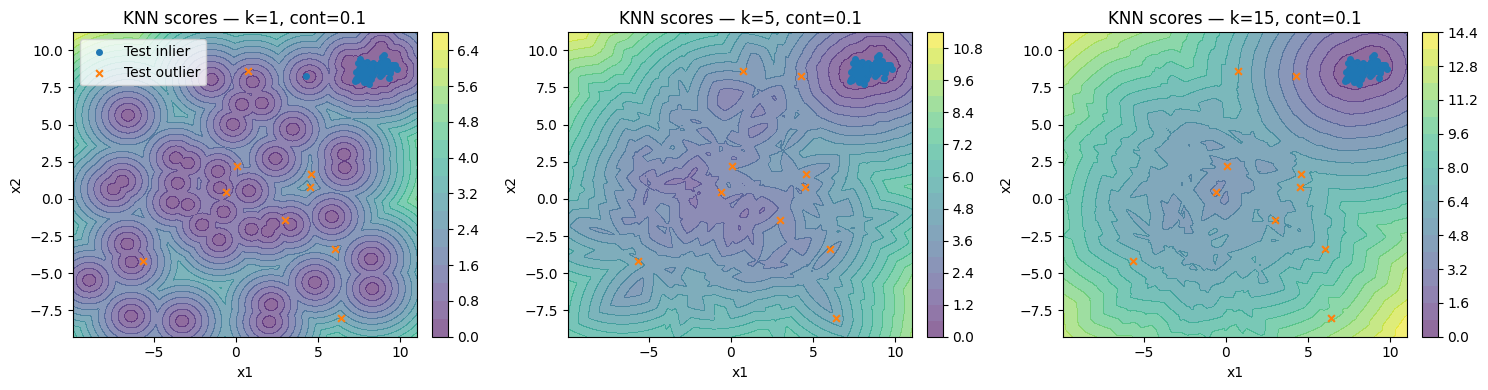

In [11]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_knn_scores_for_k_list(k_list, contamination=0.1, grid_res=200):
   
    x1_min, x1_max = X_train[:,0].min()-1.0, X_train[:,0].max()+1.0
    x2_min, x2_max = X_train[:,1].min()-1.0, X_train[:,1].max()+1.0
    xx1 = np.linspace(x1_min, x1_max, grid_res)
    xx2 = np.linspace(x2_min, x2_max, grid_res)
    XX1, XX2 = np.meshgrid(xx1, xx2)
    Grid = np.c_[XX1.ravel(), XX2.ravel()]

    fig, axes = plt.subplots(1, len(k_list), figsize=(5*len(k_list), 4), squeeze=False)
    for j, k in enumerate(k_list):
        ax = axes[0, j]
        clf = KNN(n_neighbors=k, contamination=contamination).fit(X_train)

        scores_grid = clf.decision_function(Grid).reshape(XX1.shape)

        cf = ax.contourf(XX1, XX2, scores_grid, levels=20, alpha=0.6)
        fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)

        y_pred = clf.predict(X_test).astype(int)
        mask_in = (y_pred == 0)
        mask_out = (y_pred == 1)

        ax.scatter(X_test[mask_in,0],  X_test[mask_in,1], s=16, label="Test inlier")
        ax.scatter(X_test[mask_out,0], X_test[mask_out,1], s=24, marker="x", label="Test outlier")

        ax.set_title(f"KNN scores — k={k}, cont={contamination}")
        ax.set_xlabel("x1"); ax.set_ylabel("x2")
        if j == 0:
            ax.legend()

    plt.tight_layout()
    plt.show()

plot_knn_scores_for_k_list([1, 5, 15], contamination=0.10)

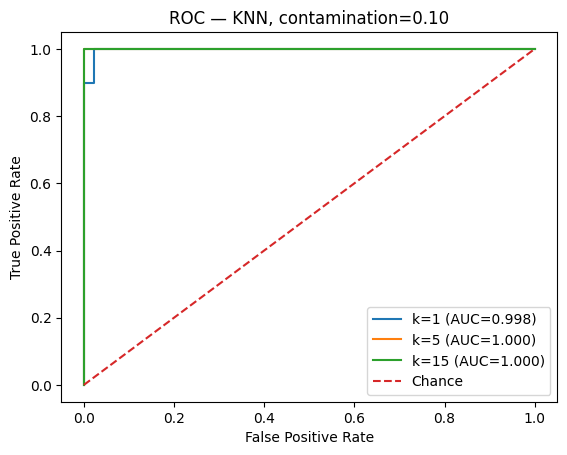

In [12]:
plt.figure()
for k in [1, 5, 15]:
    ba, auc_val, cm, fpr, tpr_pts = eval_knn(X_train, X_test, y_test, k=k, contamination=0.10)
    plt.plot(fpr, tpr_pts, label=f"k={k} (AUC={auc_val:.3f})")
plt.plot([0,1],[0,1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — KNN, contamination=0.10")
plt.legend()
plt.show()

In [13]:
#----------------------------------EX3-----------------------------------------

from pyod.models.lof import LOF
from sklearn.metrics import confusion_matrix, roc_curve, auc

def eval_lof(X_train, X_test, y_test, k=10, contamination=0.1):
   
    clf = LOF(n_neighbors=k, contamination=contamination)
    clf.fit(X_train)

    y_pred = clf.predict(X_test)
    scores = clf.decision_function(X_test)  

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    tpr = tp / (tp + fn) if (tp + fn) else 0.0
    tnr = tn / (tn + fp) if (tn + fp) else 0.0
    ba  = 0.5*(tpr + tnr)

    fpr, tpr_pts, _ = roc_curve(y_test, scores)
    auc_val = auc(fpr, tpr_pts)
    return ba, auc_val, (tn, fp, fn, tp), fpr, tpr_pts


In [14]:
ks = [5, 10, 20]
conts = [0.05, 0.10, 0.20]

results = []
for k in ks:
    for c in conts:
        ba, auc_val, (tn, fp, fn, tp), _, _ = eval_lof(X_train, X_test, y_test, k=k, contamination=c)
        results.append((k, c, ba, auc_val, tn, fp, fn, tp))

print("k  | cont  |  BA     |  AUC    |  TN  FP  FN  TP")
print("-"*55)
for k, c, ba, auc_val, tn, fp, fn, tp in results:
    print(f"{k:<3}| {c:<5} | {ba:>6.3f} | {auc_val:>6.3f} | {tn:>3} {fp:>3} {fn:>3} {tp:>3}")

k  | cont  |  BA     |  AUC    |  TN  FP  FN  TP
-------------------------------------------------------
5  | 0.05  |  0.544 |  0.480 |  89   1   9   1
5  | 0.1   |  0.528 |  0.480 |  86   4   9   1
5  | 0.2   |  0.489 |  0.480 |  79  11   9   1
10 | 0.05  |  0.594 |  0.534 |  89   1   8   2
10 | 0.1   |  0.617 |  0.534 |  84   6   7   3
10 | 0.2   |  0.583 |  0.534 |  78  12   7   3
20 | 0.05  |  0.633 |  0.557 |  87   3   7   3
20 | 0.1   |  0.611 |  0.557 |  83   7   7   3
20 | 0.2   |  0.639 |  0.557 |  79  11   6   4


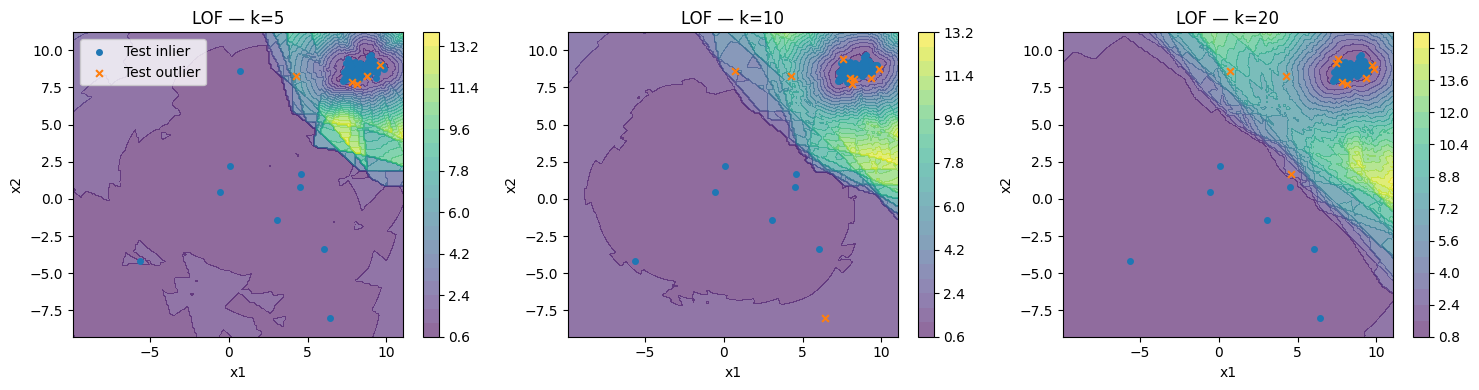

In [15]:
import matplotlib.pyplot as plt

def plot_lof_scores_for_k_list(k_list, contamination=0.1, grid_res=200):
    x1_min, x1_max = X_train[:,0].min()-1.0, X_train[:,0].max()+1.0
    x2_min, x2_max = X_train[:,1].min()-1.0, X_train[:,1].max()+1.0
    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, grid_res),
        np.linspace(x2_min, x2_max, grid_res)
    )
    Grid = np.c_[xx1.ravel(), xx2.ravel()]

    fig, axes = plt.subplots(1, len(k_list), figsize=(5*len(k_list), 4), squeeze=False)
    for j, k in enumerate(k_list):
        ax = axes[0, j]
        clf = LOF(n_neighbors=k, contamination=contamination).fit(X_train)
        scores_grid = clf.decision_function(Grid).reshape(xx1.shape)

        cf = ax.contourf(xx1, xx2, scores_grid, levels=20, alpha=0.6)
        fig.colorbar(cf, ax=ax)
        
        y_pred = clf.predict(X_test)
        mask_in = (y_pred == 0)
        mask_out = (y_pred == 1)
        ax.scatter(X_test[mask_in,0],  X_test[mask_in,1], s=16, label="Test inlier")
        ax.scatter(X_test[mask_out,0], X_test[mask_out,1], s=24, marker="x", label="Test outlier")

        ax.set_title(f"LOF — k={k}")
        ax.set_xlabel("x1"); ax.set_ylabel("x2")
        if j == 0:
            ax.legend()

    plt.tight_layout()
    plt.show()

plot_lof_scores_for_k_list([5, 10, 20], contamination=0.10)


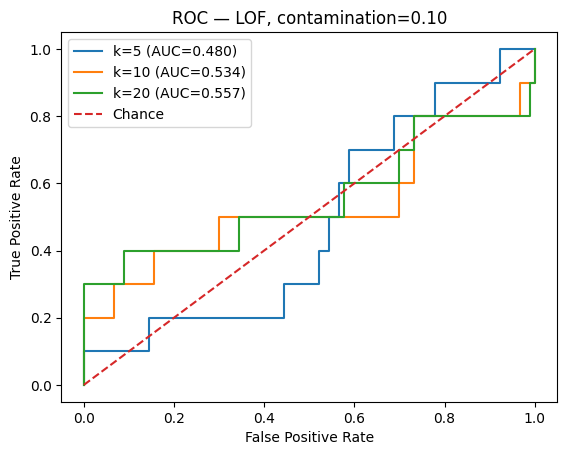

In [16]:
plt.figure()
for k in [5, 10, 20]:
    ba, auc_val, cm, fpr, tpr_pts = eval_lof(X_train, X_test, y_test, k=k, contamination=0.10)
    plt.plot(fpr, tpr_pts, label=f"k={k} (AUC={auc_val:.3f})")

plt.plot([0,1],[0,1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — LOF, contamination=0.10")
plt.legend()
plt.show()


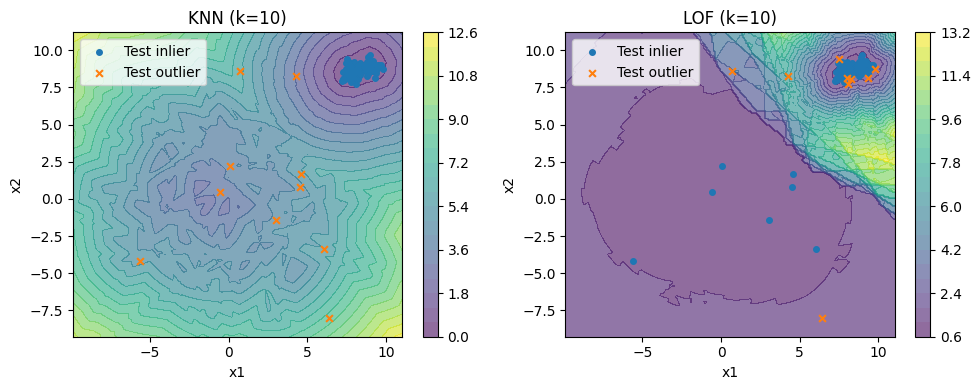

In [17]:
import matplotlib.pyplot as plt
from pyod.models.knn import KNN
from pyod.models.lof import LOF

def plot_knn_vs_lof(k=10, contamination=0.1, grid_res=200):
    
    x1_min, x1_max = X_train[:,0].min()-1, X_train[:,0].max()+1
    x2_min, x2_max = X_train[:,1].min()-1, X_train[:,1].max()+1
    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, grid_res),
        np.linspace(x2_min, x2_max, grid_res)
    )
    Grid = np.c_[xx1.ravel(), xx2.ravel()]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), squeeze=False)

    #KNN 
    ax = axes[0, 0]
    knn = KNN(n_neighbors=k, contamination=contamination).fit(X_train)
    scores_knn = knn.decision_function(Grid).reshape(xx1.shape)
    cf = ax.contourf(xx1, xx2, scores_knn, levels=20, alpha=0.6)
    fig.colorbar(cf, ax=ax)
    y_pred_knn = knn.predict(X_test)
    ax.scatter(X_test[y_pred_knn==0,0], X_test[y_pred_knn==0,1], s=16, label="Test inlier")
    ax.scatter(X_test[y_pred_knn==1,0], X_test[y_pred_knn==1,1], s=24, marker="x", label="Test outlier")
    ax.set_title(f"KNN (k={k})")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.legend()

    #LOF
    ax = axes[0, 1]
    lof = LOF(n_neighbors=k, contamination=contamination).fit(X_train)
    scores_lof = lof.decision_function(Grid).reshape(xx1.shape)
    cf = ax.contourf(xx1, xx2, scores_lof, levels=20, alpha=0.6)
    fig.colorbar(cf, ax=ax)
    y_pred_lof = lof.predict(X_test)
    ax.scatter(X_test[y_pred_lof==0,0], X_test[y_pred_lof==0,1], s=16, label="Test inlier")
    ax.scatter(X_test[y_pred_lof==1,0], X_test[y_pred_lof==1,1], s=24, marker="x", label="Test outlier")
    ax.set_title(f"LOF (k={k})")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.legend()

    plt.tight_layout()
    plt.show()

plot_knn_vs_lof(k=10, contamination=0.10)



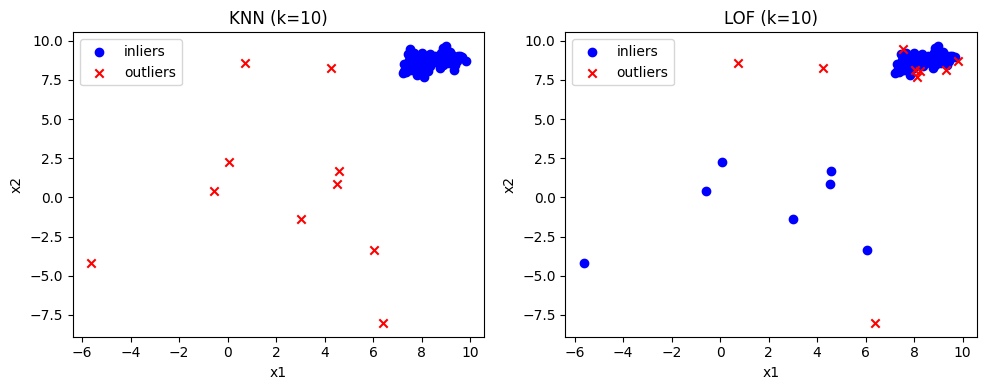

In [18]:
import matplotlib.pyplot as plt
from pyod.models.knn import KNN
from pyod.models.lof import LOF

def plot_knn_vs_lof_scatter(k=10, contamination=0.1):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), squeeze=False)

    knn = KNN(n_neighbors=k, contamination=contamination).fit(X_train)
    y_pred_knn = knn.predict(X_test)

    ax = axes[0, 0]
    ax.scatter(X_test[y_pred_knn==0,0], X_test[y_pred_knn==0,1], 
               c="blue", marker="o", label="inliers")
    ax.scatter(X_test[y_pred_knn==1,0], X_test[y_pred_knn==1,1], 
               c="red", marker="x", label="outliers")
    ax.set_title(f"KNN (k={k})")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend()

    lof = LOF(n_neighbors=k, contamination=contamination).fit(X_train)
    y_pred_lof = lof.predict(X_test)

    ax = axes[0, 1]
    ax.scatter(X_test[y_pred_lof==0,0], X_test[y_pred_lof==0,1], 
               c="blue", marker="o", label="inliers")
    ax.scatter(X_test[y_pred_lof==1,0], X_test[y_pred_lof==1,1], 
               c="red", marker="x", label="outliers")
    ax.set_title(f"LOF (k={k})")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend()

    plt.tight_layout()
    plt.show()

plot_knn_vs_lof_scatter(k=10, contamination=0.10)


In [19]:
from scipy.io import loadmat

data = loadmat("cardio.mat")
print(data.keys())


dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])


In [21]:
#------------------------------EX4-------------------------------

from scipy.io import loadmat
import numpy as np

data = loadmat("cardio.mat")
X = data["X"]
y = data["y"].ravel()

uniq = np.unique(y)
if set(uniq.tolist()) == {0,1}:
    y = y.astype(int)
elif set(uniq.tolist()) == {1,2}:
    y = (y == 2).astype(int)   
else:
    y = (y == uniq.max()).astype(int)

X.shape, np.bincount(y)


((1831, 21), array([1655,  176]))